## <center>Global Cost of Living Analysis Using World Bank PLI Data (1990 - 2024)</center>

In [4]:
import pandas as pd
import numpy as np
import matplotlib as plt

In [5]:
df = pd.read_csv("data/raw_data_of_world_bank_PLI.csv")

In [6]:
# Select relevant columns
df_clean = df[['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE']]

In [7]:
# Rename for clarity
df_clean.columns = ['Country', 'Year', 'PLI']

In [8]:
# Drop missing values
df_clean = df_clean.dropna()

In [9]:
# Convert types
df_clean['Year'] = df_clean['Year'].astype(int)
df_clean['PLI'] = df_clean['PLI'].astype(float)

In [10]:
df_clean['Real_Power_Index'] = 100 / df_clean['PLI']

In [11]:
df_clean.head()

,Country,Year,PLI,Real_Power_Index
0,Uzbekistan,1999,29.497896,3.390072
1,Vanuatu,1999,70.644346,1.415541
2,"Venezuela, RB",1999,36.586214,2.733270
3,Vietnam,1999,19.720012,5.070991
4,West Bank and Gaza,1999,51.507000,1.941484


Download Cleaned data

In [12]:
df_clean.to_csv("cleaned_data.csv", index=False)

<Axes: title={'center': 'Global Average Price Level Index Over Time'}, xlabel='Year'>

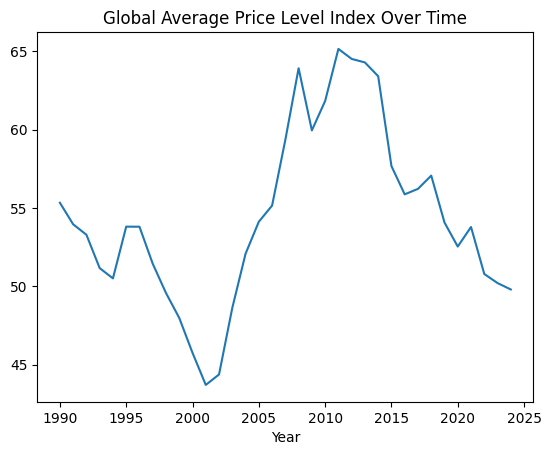

In [13]:
global_trend = df_clean.groupby('Year')['PLI'].mean()
global_trend.plot(title="Global Average Price Level Index Over Time")

### Define Economic Meaning of Thresholds

Since: PLI = 100 → USA baseline

We define:

| Category | PLI Range | Meaning |
|---|---|---|
|🟢 Cheap |	PLI < 60 |	Low cost of living |
|🟡 Moderate |	60 ≤ PLI ≤ 100 | Mid-range |
|🔴 Expensive |	PLI > 100 |	High cost |

These are interpretable thresholds, not arbitrary.

In [14]:
def classify_pli(pli):
    if pli < 60:
        return "Cheap"
    elif pli <= 100:
        return "Moderate"
    else:
        return "Expensive"

# Apply to dataset
df_clean['Category'] = df_clean['PLI'].apply(classify_pli)

df_clean.head()

,Country,Year,PLI,Real_Power_Index,Category
0,Uzbekistan,1999,29.497896,3.390072,Cheap
1,Vanuatu,1999,70.644346,1.415541,Moderate
2,"Venezuela, RB",1999,36.586214,2.733270,Cheap
3,Vietnam,1999,19.720012,5.070991,Cheap
4,West Bank and Gaza,1999,51.507000,1.941484,Cheap


In [15]:
latest_year = df_clean['Year'].max()

top_expensive = df_clean[df_clean['Year'] == latest_year] \
    .sort_values(by='PLI', ascending=False) \
    .head(10)

top_expensive

,Country,Year,PLI,Real_Power_Index,Category
6742,Bermuda,2024,114.971521,0.869781,Expensive
6792,Switzerland,2024,110.500213,0.904976,Expensive
6737,Barbados,2024,106.938600,0.935116,Expensive
6536,Iceland,2024,102.754523,0.973193,Expensive
6684,United States,2024,100.000000,1.000000,Moderate
6679,Turks and Caicos Islands,2024,98.820669,1.011934,Moderate
6641,Nauru,2024,96.021668,1.041432,Moderate
6755,"Micronesia, Fed. Sts.",2024,95.839791,1.043408,Moderate
6734,"Bahamas, The",2024,95.770449,1.044163,Moderate
6542,Israel,2024,94.655280,1.056465,Moderate


<Axes: title={'center': 'India vs USA PLI Comparison'}, xlabel='Year'>

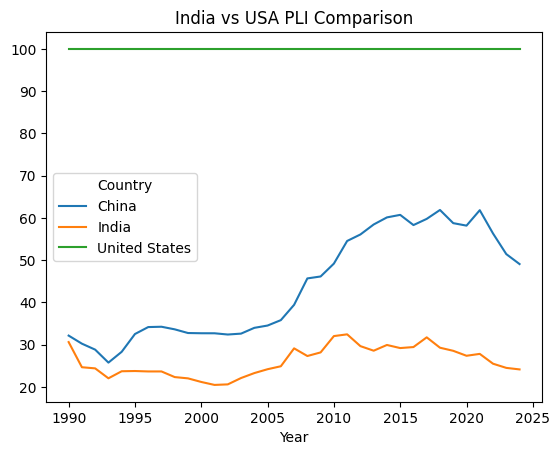

In [16]:
countries = ['India','China', 'United States']

comparison = df_clean[df_clean['Country'].isin(countries)]

pivot = comparison.pivot(index='Year', columns='Country', values='PLI')
pivot.plot(title="India vs USA PLI Comparison")

Count of Countries in Each Category

In [17]:
df_clean['Category'].value_counts()

Category
Cheap        4562
Moderate     1681
Expensive     592
Name: count, dtype: int64

Visualization (Distribution)

<Axes: title={'center': 'Country Cost Categories'}, xlabel='Category'>

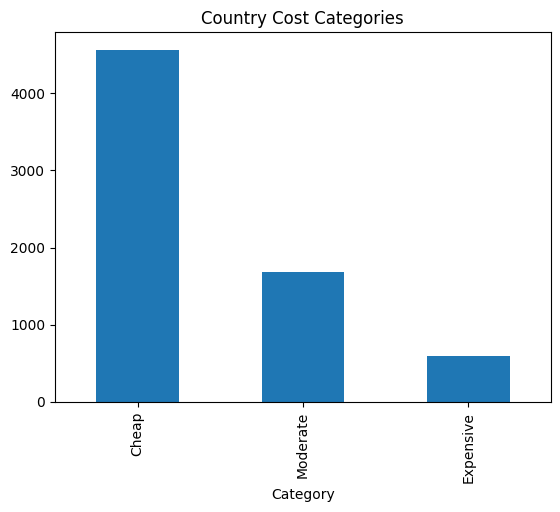

In [18]:
df_clean['Category'].value_counts().plot(kind='bar', title='Country Cost Categories')

Latest Year Classification

In [19]:
latest_year = df_clean['Year'].max()

latest_data = df_clean[df_clean['Year'] == latest_year]

latest_data[['Country', 'PLI', 'Category']].sort_values(by='PLI', ascending=False)

,Country,PLI,Category
6742,Bermuda,114.971521,Expensive
6792,Switzerland,110.500213,Expensive
6737,Barbados,106.938600,Expensive
6536,Iceland,102.754523,Expensive
6684,United States,100.000000,Moderate
...,...,...,...
6761,Myanmar,22.660407,Cheap
6569,Lao PDR,21.726846,Cheap
6584,Burundi,18.362728,Cheap
6702,"Egypt, Arab Rep.",17.484280,Cheap


## Core Problem with Fixed Thresholds

Fixed thresholds assume:

“Economic structure is constant” -> That’s false.

Issues:
- Global prices change over time
- Dataset distribution shifts
- Same threshold becomes misleading

## Dynamic categories use data distribution (quantiles):

- Bottom 33% → Cheap
- Middle 33% → Moderate
- Top 33% → Expensive

It adapts to actual data behavior

In [20]:
q1 = df_clean['PLI'].quantile(0.33)
q2 = df_clean['PLI'].quantile(0.66)

def classify_dynamic(pli):
    if pli < q1:
        return "Cheap"
    elif pli < q2:
        return "Moderate"
    else:
        return "Expensive"

df_clean['Dynamic_Category'] = df_clean['PLI'].apply(classify_dynamic)

In [21]:
df_clean.describe()

,Year,PLI,Real_Power_Index
count,6835.000000,6835.000000,6835.000000
mean,2007.226920,54.512455,2.402629
std,10.025232,28.087939,2.653345
min,1990.000000,0.851960,0.486107
25%,1999.000000,33.783667,1.463804
50%,2007.000000,46.618719,2.145061
75%,2016.000000,68.315150,2.960010
max,2024.000000,205.715819,117.376430


In [22]:
df_clean[['PLI', 'Real_Power_Index']].head()

,PLI,Real_Power_Index
0,29.497896,3.390072
1,70.644346,1.415541
2,36.586214,2.733270
3,19.720012,5.070991
4,51.507000,1.941484


In [23]:
df_filtered = df_clean[(df_clean['PLI'] > 10) & (df_clean['PLI'] < 150)]

In [24]:
df_clean.describe()

,Year,PLI,Real_Power_Index
count,6835.000000,6835.000000,6835.000000
mean,2007.226920,54.512455,2.402629
std,10.025232,28.087939,2.653345
min,1990.000000,0.851960,0.486107
25%,1999.000000,33.783667,1.463804
50%,2007.000000,46.618719,2.145061
75%,2016.000000,68.315150,2.960010
max,2024.000000,205.715819,117.376430


<Axes: title={'center': 'PLI vs Purchasing Power'}, xlabel='PLI', ylabel='Real_Power_Index'>

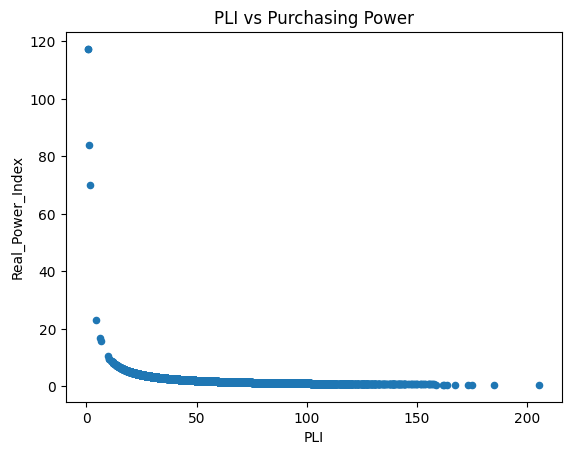

In [25]:
df_clean.plot.scatter(x='PLI', y='Real_Power_Index', title='PLI vs Purchasing Power')

In [26]:
df_filtered = df_clean[df_clean['PLI'] <= 120]

In [27]:
df_filtered.describe()

,Year,PLI,Real_Power_Index
count,6626.000000,6626.000000,6626.000000
mean,2007.324027,51.980169,2.454820
std,10.059231,24.469478,2.678267
min,1990.000000,0.851960,0.835647
25%,1999.000000,33.437880,1.530685
50%,2007.000000,45.780922,2.184316
75%,2016.000000,65.330209,2.990620
max,2024.000000,119.667734,117.376430


In [28]:
len(df) - len(df_filtered)

209

In [29]:
df_filtered =df_clean[(df_clean['PLI'] > 10) & (df_clean['PLI'] <= 120)]

<Axes: >

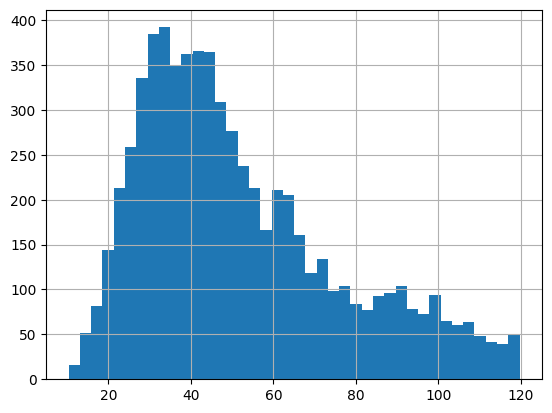

In [30]:
df_filtered['PLI'].hist(bins=40)

In [31]:
latest = df_filtered[df_filtered['Year'] == df_filtered['Year'].max()]
latest.sort_values(by='PLI', ascending=False).head(10)

,Country,Year,PLI,Real_Power_Index,Category,Dynamic_Category
6742,Bermuda,2024,114.971521,0.869781,Expensive,Expensive
6792,Switzerland,2024,110.500213,0.904976,Expensive,Expensive
6737,Barbados,2024,106.938600,0.935116,Expensive,Expensive
6536,Iceland,2024,102.754523,0.973193,Expensive,Expensive
6684,United States,2024,100.000000,1.000000,Moderate,Expensive
6679,Turks and Caicos Islands,2024,98.820669,1.011934,Moderate,Expensive
6641,Nauru,2024,96.021668,1.041432,Moderate,Expensive
6755,"Micronesia, Fed. Sts.",2024,95.839791,1.043408,Moderate,Expensive
6734,"Bahamas, The",2024,95.770449,1.044163,Moderate,Expensive
6542,Israel,2024,94.655280,1.056465,Moderate,Expensive


In [32]:
df_filtered[['PLI', 'Real_Power_Index']].corr()

,PLI,Real_Power_Index
PLI,1.000000,-0.852105
Real_Power_Index,-0.852105,1.000000


In [33]:
latest.sort_values(by='PLI').head(10)

,Country,Year,PLI,Real_Power_Index,Category,Dynamic_Category
6647,Nigeria,2024,11.931058,8.381486,Cheap,Cheap
6702,"Egypt, Arab Rep.",2024,17.484280,5.719423,Cheap,Cheap
6584,Burundi,2024,18.362728,5.445814,Cheap,Cheap
6569,Lao PDR,2024,21.726846,4.602601,Cheap,Cheap
6761,Myanmar,2024,22.660407,4.412983,Cheap,Cheap
6776,Sierra Leone,2024,22.901323,4.366560,Cheap,Cheap
6651,Pakistan,2024,23.652359,4.227908,Cheap,Cheap
6537,India,2024,24.146427,4.141399,Cheap,Cheap
6793,Tajikistan,2024,24.809605,4.030697,Cheap,Cheap
6664,"Gambia, The",2024,25.070122,3.988812,Cheap,Cheap


## Final Story
This analysis examines global cost-of-living differences using the World Bank’s Price Level Index (PLI) dataset from 1990 to 2024, where PLI measures how expensive a country is relative to the United States (base = 100). After cleaning and structuring the data, additional features such as a Real Power Index (inverse of PLI) and both fixed and dynamic classifications were created to capture absolute and relative economic positions. Statistical analysis revealed that the global average PLI is around 52, with a median near 46, indicating that most countries are significantly cheaper than the United States, offering roughly 2–3 times higher purchasing power for the same amount of money. The distribution is right-skewed, showing that while the majority of countries fall into the low-cost category, a small group of high-income and island economies—such as Bermuda, Switzerland, and Iceland—exhibit very high price levels due to factors like strong currencies, high wages, and import dependency. Outliers were identified and handled using the IQR method to ensure robust insights without distortion from extreme values. Trend analysis suggests periods of global price convergence and divergence, reflecting shifts in economic development and currency dynamics over time. Comparative analysis across countries highlights a clear structural divide between developing economies with low cost levels and developed economies with high cost structures. Overall, the study demonstrates that global purchasing power is highly uneven, with most countries remaining relatively affordable compared to developed benchmarks, providing valuable insights for economic policy, international business strategy, and cost-of-living comparisons.

In [34]:
df_filtered.to_csv("filtered_data.csv", index=False)